# Create Agent

In [ ]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage
model = init_chat_model("groq:openai/gpt-oss-20b") 
# make sure that your api key is set through dotenv or if in colab through colab secrets
# in case of collab pass the api key as
# init_chat_model("groq:openai/gpt-oss-20b", api_key=GROQ_API_KEU)
# also langchain_groq should be installed, do you know why?


In [151]:
# Defining tools

def add(a:int, b:int):
    """A function to add two numbers"""
    return a+b

def mul(a:int, b:int):
    """A function to find product of two numebers"""
    return a*b

In [ ]:
agent = create_agent(model, system_prompt="You are a helpful assistant, always use add tool for additions and for product using mul tool", tools=[add, mul])

In [133]:
response = agent.invoke({"messages":[HumanMessage("what is sum of 20 and 30 and what is their product")]})

In [134]:
from pprint import pprint
pprint(response)

{'messages': [HumanMessage(content='what is sum of 20 and 30 and what is their product', additional_kwargs={}, response_metadata={}, id='110d24a1-a771-4c60-9a95-175e2b7ff04b'),
              AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants sum of 20 and 30 and product. We have to use add tool for sum, mul tool for product. So we must call add with a=20, b=30. Then mul with same. Then combine results.', 'tool_calls': [{'id': 'fc_9e887b90-4da7-40cf-a6c4-a650597d4f65', 'function': {'arguments': '{"a":20,"b":30}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 76, 'prompt_tokens': 189, 'total_tokens': 265, 'completion_time': 0.079712814, 'completion_tokens_details': {'reasoning_tokens': 50}, 'prompt_time': 0.0091281, 'prompt_tokens_details': None, 'queue_time': 0.261263349, 'total_time': 0.088840914}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_851252edc2', 'service_tier': 'on_demand', 'finish_reason

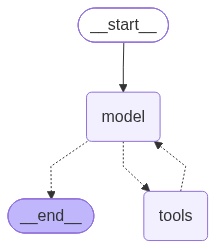

In [135]:
agent

In [136]:
type(agent)

langgraph.graph.state.CompiledStateGraph

# Dropping down to langgraph graph

In [137]:
from typing import TypedDict, Annotated
import operator
from langchain.messages import AnyMessage, HumanMessage

class chatState(TypedDict):
    messages:Annotated[list[AnyMessage], operator.add]

In [138]:
from langgraph.graph import StateGraph, START, END
builder = StateGraph(chatState)

In [139]:
# Defining the model node in the graph
def model_node(state:chatState) -> dict:
    response = agent.invoke(state)
    return {"messages":response["messages"]}# There is a little problem here, find it!
 
# Adding the model node to the graph
builder.add_node("model_node", model_node)

# Connecting the start and end nodes to the model node
builder.add_edge(START, "model_node")
builder.add_edge("model_node", END)

In [140]:
graph = builder.compile()

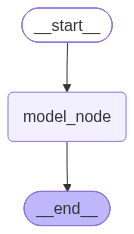

In [141]:
graph

In [142]:
# langgraph Workflow/Agent takes State as input and after whole execution, returns the updated state as output state. The input state is passed to the first node in the graph and the output of each node is passed to the next node in the graph. The final output state is returned as the output of the workflow.
inputState = chatState(messages=[HumanMessage("Hello, add 2 and 3")])
outputState = graph.invoke({"messages":[HumanMessage("Hello, add 2 and 3")]})

In [143]:
type(outputState) # why Should it be type of dict? -> Because it is our state which is dictionary

dict

In [147]:
pprint(outputState)

{'messages': [HumanMessage(content='Hello, add 2 and 3', additional_kwargs={}, response_metadata={}, id='b99da738-4363-4efb-97cb-b0f8d38822a6'),
              HumanMessage(content='Hello, add 2 and 3', additional_kwargs={}, response_metadata={}, id='b99da738-4363-4efb-97cb-b0f8d38822a6'),
              AIMessage(content='', additional_kwargs={'reasoning_content': 'User says: "Hello, add 2 and 3". We need to use the add tool. The instruction: "You are a helpful assistant, always use add tool for additions and also for product using mul method". So we must call the add function.', 'tool_calls': [{'id': 'fc_0a5a0d44-17c3-46bc-a1f2-f678635f3c52', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 183, 'total_tokens': 263, 'completion_time': 0.081925608, 'completion_tokens_details': {'reasoning_tokens': 54}, 'prompt_time': 0.008796307, 'prompt_tokens_details': None, 'queue_time': 0.76

# What's missing